# 02 EDA Base Tickets

Este notebook toma el `Parquet` de la etapa `01`, prepara la base para analisis exploratorio y genera el `Parquet` oficial de la etapa `02`.


## 1. Librerias


In [1]:
# Manejo de rutas internas del proyecto.
from pathlib import Path
# Lectura y transformacion tabular de la base de tickets.
import pandas as pd
# Graficas base del analisis exploratorio.
import matplotlib.pyplot as plt
# Visualizaciones estadisticas para EDA.
import seaborn as sns


### Para que se usan estas librerias

- `Path`: localizar la raiz del proyecto y construir rutas de entrada y salida.
- `pandas`: leer el parquet del paso `01`, crear variables derivadas y exportar la base `EDA`.
- `matplotlib`: construir las figuras generales del analisis exploratorio.
- `seaborn`: generar histogramas y boxplots para revisar la distribucion de los tickets.


## 2. Definir rutas


In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    # Buscar la raiz del proyecto a partir del directorio actual.
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "parquets").exists():
            return candidate
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto")

PROJECT_ROOT = resolve_project_root()

# Definir el parquet de entrada y la salida de la etapa 02.
INPUT_PATH = PROJECT_ROOT / "parquets" / "01_Carga_y_Validacion_Parquet" / "01_base_tickets_modelado.parquet"
OUTPUT_DIR = PROJECT_ROOT / "parquets" / "02_EDA_Base_Tickets"
OUTPUT_PATH = OUTPUT_DIR / "02_base_eda_tickets.parquet"

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Parquet de entrada: {INPUT_PATH}")
print(f"Parquet de salida: {OUTPUT_PATH}")


Raiz del proyecto: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning
Parquet de entrada: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\01_Carga_y_Validacion_Parquet\01_base_tickets_modelado.parquet
Parquet de salida: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\02_EDA_Base_Tickets\02_base_eda_tickets.parquet


## 3. Cargar la base de entrada


In [3]:
# Leer la base principal generada en la etapa 01.
df = pd.read_parquet(INPUT_PATH)

# Mostrar las primeras filas del dataset base.
df.head()


,id_ticket_modelado,id_tiempo,fecha,dia,mes,nombre_mes,trimestre,anio,dia_semana,fin_semana,...,categorias_distintas,subtotal_ticket,total_pedido,monto_pago,diferencia_pago,incluye_bebida,incluye_postre,incluye_entrada,incluye_platillo_fuerte,ticket_alto
0,1,1,2024-01-02,2,1,Enero,1,2024,Martes,False,...,3,945.0,250.0,250.0,0.0,0,0,0,1,0
1,2,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,10,3865.0,285.0,285.0,0.0,1,1,1,1,0
2,3,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,10,5170.0,420.0,420.0,0.0,1,1,1,1,0
3,4,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,5,1485.0,370.0,305.0,-65.0,1,0,0,1,0
4,5,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,1,210.0,335.0,335.0,0.0,0,0,0,1,0


### Resultado

La carga del parquet `01_base_tickets_modelado.parquet` se realizo correctamente.

La vista previa muestra `5 filas x 36 columnas`, lo que confirma que el notebook `02` ya parte de una base consolidada por ticket.

En las primeras filas se observan variables clave como:

- `fecha`
- `ciudad`
- `metodo_pago`
- `subtotal_ticket`
- `total_pedido`
- `monto_pago`
- `ticket_alto`

Con esto se confirma que la entrada del `EDA` ya no sale directo de la base de datos, sino del parquet generado en la etapa `01`.


## 4. Crear variables derivadas para EDA


In [4]:
# Generar columnas auxiliares para revisar calendario y consistencia.
df["anio_mes"] = pd.to_datetime(df["fecha"]).dt.strftime("%Y-%m")
df["dia_tipo"] = df["fin_semana"].map({True: "Fin de semana", False: "Entre semana"})
df["residuo_subtotal_total"] = df["subtotal_ticket"] - df["total_pedido"]
df["residuo_abs_subtotal_total"] = df["residuo_subtotal_total"].abs()
df["residuo_pago_total"] = df["monto_pago"] - df["total_pedido"]
df["ticket_consistente_subtotal"] = (df["residuo_abs_subtotal_total"] <= 0.01).astype(int)
df["ticket_consistente_pago"] = (df["residuo_pago_total"].abs() <= 0.01).astype(int)
df["rango_total_pedido"] = pd.cut(
    df["total_pedido"],
    bins=[0, 300, 520, float("inf")],
    labels=["Bajo", "Medio", "Alto"],
    include_lowest=True,
)

df.head()


,id_ticket_modelado,id_tiempo,fecha,dia,mes,nombre_mes,trimestre,anio,dia_semana,fin_semana,...,incluye_platillo_fuerte,ticket_alto,anio_mes,dia_tipo,residuo_subtotal_total,residuo_abs_subtotal_total,residuo_pago_total,ticket_consistente_subtotal,ticket_consistente_pago,rango_total_pedido
0,1,1,2024-01-02,2,1,Enero,1,2024,Martes,False,...,1,0,2024-01,Entre semana,695.0,695.0,0.0,0,1,Bajo
1,2,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,1,0,2024-01,Entre semana,3580.0,3580.0,0.0,0,1,Bajo
2,3,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,1,0,2024-01,Entre semana,4750.0,4750.0,0.0,0,1,Medio
3,4,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,1,0,2024-01,Entre semana,1115.0,1115.0,-65.0,0,0,Medio
4,5,2,2024-01-03,3,1,Enero,1,2024,Miércoles,False,...,1,0,2024-01,Entre semana,-125.0,125.0,0.0,0,1,Medio


### Resultado

Despues de crear las variables derivadas, la base en memoria pasa a mostrar `44 columnas` en la vista previa.

Las nuevas columnas agregadas para esta etapa son:

- `anio_mes`
- `dia_tipo`
- `residuo_subtotal_total`
- `residuo_abs_subtotal_total`
- `residuo_pago_total`
- `ticket_consistente_subtotal`
- `ticket_consistente_pago`
- `rango_total_pedido`

Estas variables permiten revisar calendario, consistencia de montos y clasificacion general del ticket antes de pasar a los modelos.


## 5. Revisar consistencia y distribuciones


In [5]:
# Resumir la consistencia observada en subtotales y pagos.
df[["ticket_consistente_subtotal", "ticket_consistente_pago"]].sum()


ticket_consistente_subtotal      9
ticket_consistente_pago        930
dtype: int64

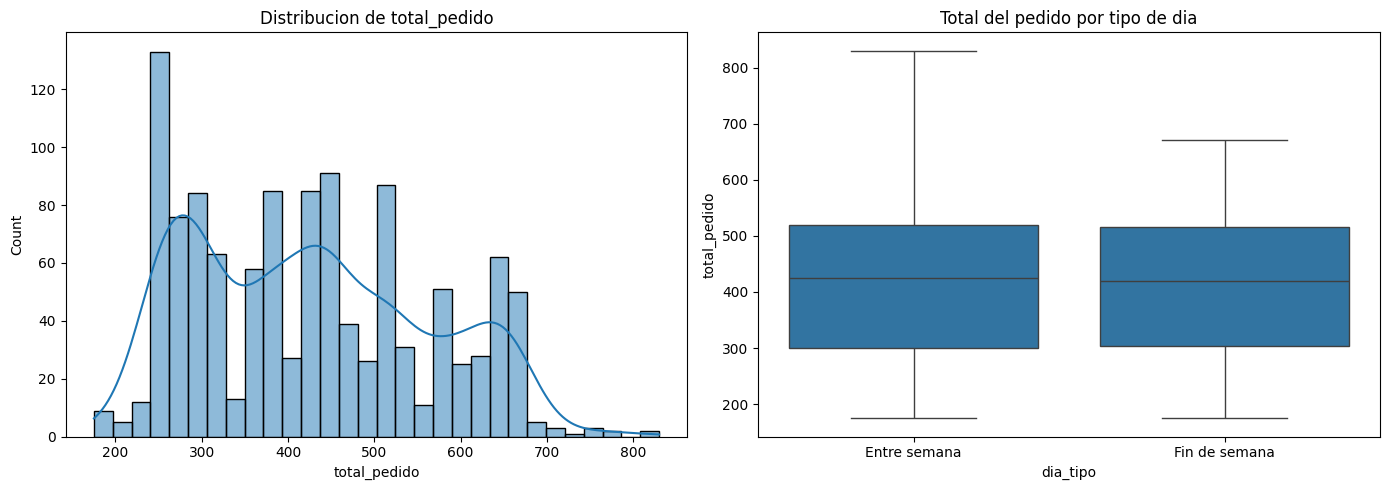

In [6]:
# Graficar la distribucion del total del pedido y una comparacion por tipo de dia.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["total_pedido"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de total_pedido")
axes[0].set_xlabel("total_pedido")

sns.boxplot(data=df, x="dia_tipo", y="total_pedido", ax=axes[1])
axes[1].set_title("Total del pedido por tipo de dia")
axes[1].set_xlabel("dia_tipo")
axes[1].set_ylabel("total_pedido")
plt.tight_layout()


### Resultado

La revision de consistencia mostro dos resultados importantes:

- `ticket_consistente_subtotal = 9`
- `ticket_consistente_pago = 930`

Esto indica que la relacion entre `monto_pago` y `total_pedido` es mucho mas estable que la relacion entre `subtotal_ticket` y `total_pedido`.

En las graficas tambien se observa:

- la distribucion general de `total_pedido`
- la comparacion del ticket entre `Entre semana` y `Fin de semana`
- la presencia de dispersion y algunos valores altos dentro del rango de pedidos


## 6. Exportar el parquet de la etapa 02


In [7]:
# Crear la carpeta de salida si todavia no existe.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Definir el orden final de columnas de la base EDA.
columnas_ordenadas = [
    "id_ticket_modelado", "fecha", "anio_mes", "dia", "mes", "nombre_mes", "trimestre", "anio",
    "dia_semana", "dia_tipo", "fin_semana", "id_cliente", "id_sucursal", "ciudad", "capacidad_sucursal",
    "id_empleado", "tipo_empleado", "salario", "turno", "id_mesa", "numero_mesa", "capacidad_mesa",
    "id_metodo_pago", "metodo_pago", "lineas_ticket", "cantidad_total", "platillos_distintos",
    "categorias_distintas", "subtotal_ticket", "total_pedido", "monto_pago", "diferencia_pago",
    "residuo_subtotal_total", "residuo_abs_subtotal_total", "residuo_pago_total", "ticket_consistente_subtotal",
    "ticket_consistente_pago", "incluye_bebida", "incluye_postre", "incluye_entrada", "incluye_platillo_fuerte",
    "ticket_alto", "rango_total_pedido"
]

df_eda = df[columnas_ordenadas].copy()
df_eda.to_parquet(OUTPUT_PATH, index=False)
print(f"Parquet generado en: {OUTPUT_PATH}")


Parquet generado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\02_EDA_Base_Tickets\02_base_eda_tickets.parquet


In [8]:
# Verificar que el parquet exportado se pueda leer correctamente.
df_eda_exportado = pd.read_parquet(OUTPUT_PATH)
df_eda_exportado.shape


(1167, 43)

### Resultado

El archivo `02_base_eda_tickets.parquet` se genero correctamente en la carpeta esperada dentro de `parquets/02_EDA_Base_Tickets`.

Despues de exportarlo se verifico su lectura y quedo confirmado que conserva una estructura de:

- `1167 filas`
- `43 columnas`

Con esto, la etapa `02` queda cerrada y el parquet resultante ya puede alimentar directamente a las etapas `03`, `04` y `05`.


## Conclusi?n

La etapa `02` enriquece la base principal con variables exploratorias y genera `02_base_eda_tickets.parquet` con `1167 filas` y `43 columnas`. Ademas, confirma que `monto_pago` resulta mas consistente que `subtotal_ticket`, lo cual orienta mejor las siguientes etapas de modelado.
